In [1]:
import requests
import pandas as pd
import numpy as np
import time
import json
import os
import getpass
import matplotlib.pyplot as plt
import seaborn as sns

# Setup folder
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/clean", exist_ok=True)
os.makedirs("../report", exist_ok=True)

# 1. INPUT TOKEN (Tidak tersimpan di kode)
print("Masukkan GitHub Personal Access Token Anda:")
print("Setup dan Library berhasil diimpor")
GITHUB_TOKEN = getpass.getpass()
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}'}
REPO = 'pandas-dev/pandas'
BASE_URL = f'https://api.github.com/repos/{REPO}'

Masukkan GitHub Personal Access Token Anda:
Setup dan Library berhasil diimpor


In [14]:
# 2. DATA FETCHING (API PR & Issues)
def fetch_github_data(endpoint, params, max_pages=20):
    all_data = []
    print(f"Mengambil data dari {endpoint}...")
    
    for page in range(1, max_pages + 1):
        params['page'] = page
        params['per_page'] = 100
        
        response = requests.get(f"https://api.github.com/repos/{REPO}/{endpoint}", headers=HEADERS, params=params)
        
        if response.status_code != 200:
            print(f"Berhenti di halaman {page}. Status code: {response.status_code}")
            break
            
        data = response.json()
        if not data:
            break # Data sudah habis
            
        all_data.extend(data)
        print(f"Halaman {page} terambil ({len(all_data)} data).")
        time.sleep(1) # Jeda sopan agar tidak kena rate limit
        
    return all_data

# 1. Fetch Pull Requests (RQ1)
pr_params = {"state": "closed", "sort": "created", "direction": "desc"}
raw_prs = fetch_github_data("pulls", pr_params, max_pages=30) # Ambil agak banyak untuk PR

# 2. Fetch Issues (RQ2 & RQ3)
issue_params = {"state": "closed", "sort": "created", "direction": "asc", "since": "2022-01-01T00:00:00Z"}
raw_issues = fetch_github_data("issues", issue_params, max_pages=50)

# Simpan data mentah sebagai backup
with open("../data/raw/raw_prs.json", "w") as f: json.dump(raw_prs, f)
with open("../data/raw/raw_issues.json", "w") as f: json.dump(raw_issues, f)

print(f"\n Selesai! Total PR ditarik: {len(raw_prs)} | Total Issue ditarik: {len(raw_issues)}")

Mengambil data dari pulls...
Halaman 1 terambil (100 data).
Halaman 2 terambil (200 data).
Halaman 3 terambil (300 data).
Halaman 4 terambil (400 data).
Halaman 5 terambil (500 data).
Halaman 6 terambil (600 data).
Halaman 7 terambil (700 data).
Halaman 8 terambil (800 data).
Halaman 9 terambil (900 data).
Halaman 10 terambil (1000 data).
Halaman 11 terambil (1100 data).
Halaman 12 terambil (1200 data).
Halaman 13 terambil (1300 data).
Halaman 14 terambil (1400 data).
Halaman 15 terambil (1500 data).
Halaman 16 terambil (1600 data).
Halaman 17 terambil (1700 data).
Halaman 18 terambil (1800 data).
Halaman 19 terambil (1900 data).
Halaman 20 terambil (2000 data).
Halaman 21 terambil (2100 data).
Halaman 22 terambil (2200 data).
Halaman 23 terambil (2300 data).
Halaman 24 terambil (2400 data).
Halaman 25 terambil (2500 data).
Halaman 26 terambil (2600 data).
Halaman 27 terambil (2700 data).
Halaman 28 terambil (2800 data).
Halaman 29 terambil (2900 data).
Halaman 30 terambil (3000 data).

In [15]:
# 3. DATA CLEANING & TRANSFORMATION
PANDAS_V2_DATE = pd.Timestamp("2023-04-03")
# CLEANING PR Logic (Untuk RQ1)
pr_list = []
for pr in raw_prs:
    if pr.get("draft") == True: continue 
    
    created = pd.Timestamp(pr["created_at"])
    closed = pd.Timestamp(pr["closed_at"]) if pr.get("closed_at") else None
    merged = True if pr.get("merged_at") else False
    
    if closed:
        days = (closed - created).total_seconds() / 86400
        if days > 0:
            pr_list.append({
                "number": pr["number"],
                "created_at": created,
                "merged": merged,
                "outcome": 1 if merged else 0, 
                "resolution_days": days
            })

df_prs = pd.DataFrame(pr_list)

# CLEANING ISSUES Logic (Untuk RQ2 & RQ3) 
issue_list = []
for issue in raw_issues:
    if "pull_request" in issue: continue # Abaikan PR yang masuk ke endpoint issues
    
    labels = [l["name"].lower() for l in issue.get("labels", [])]
    is_bug = any("bug" in l for l in labels)
    
    created = pd.Timestamp(issue["created_at"])
    closed = pd.Timestamp(issue["closed_at"]) if issue.get("closed_at") else None
    
    if closed:
        days = (closed - created).total_seconds() / 86400
        if days > 0:
            issue_list.append({
                "number": issue["number"],
                "title": issue.get("title", ""),
                "type": "bug" if is_bug else "other",
                "created_at": created,
                "resolution_days": days
            })

df_issues = pd.DataFrame(issue_list)

# Buat dataframe khusus bug per bulan untuk Poisson (RQ2)
df_issues['yearmonth'] = df_issues['created_at'].dt.to_period("M")
df_bugs = df_issues[df_issues['type'] == 'bug']
monthly_bugs = df_bugs.groupby('yearmonth').size().reset_index(name='bug_count')
monthly_bugs['period'] = monthly_bugs['yearmonth'].dt.to_timestamp().apply(
    lambda x: "post_v2" if x >= PANDAS_V2_DATE else "pre_v2"
)

# Simpan ke CSV
df_prs.to_csv("../data/clean/prs_clean.csv", index=False)
df_issues.to_csv("../data/clean/issues_full.csv", index=False)
monthly_bugs.to_csv("../data/clean/monthly_bugs.csv", index=False)
print("Data berhasil dibersihkan dan disimpan ke folder clean")

C:\Users\Darren CW\AppData\Local\Temp\ipykernel_16184\1762910057.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_issues['yearmonth'] = df_issues['created_at'].dt.to_period("M")


Data berhasil dibersihkan dan disimpan ke folder clean


C:\Users\Darren CW\AppData\Local\Temp\ipykernel_16184\962656982.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_prs, x="merged", palette=["#EF5350", "#4CAF50"])


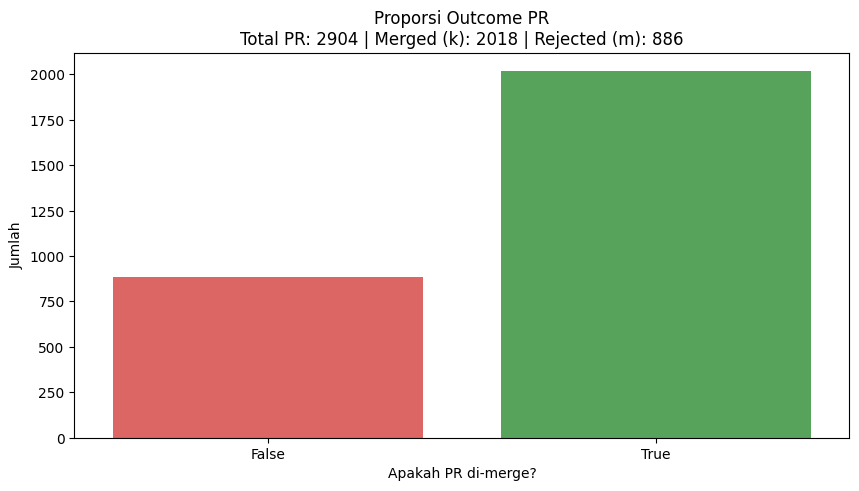

Preview Nilai MLE Bernoulli (θ̂) = 0.6949


In [16]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# Plot RQ1 
# Hitung statistik
k = df_prs["merged"].sum()
n = len(df_prs)
m = n - k

plt.figure(figsize=(10, 5))
sns.countplot(data=df_prs, x="merged", palette=["#EF5350", "#4CAF50"])
plt.title(f"Proporsi Outcome PR\nTotal PR: {n} | Merged (k): {k} | Rejected (m): {m}")
plt.xlabel("Apakah PR di-merge?")
plt.ylabel("Jumlah")
plt.show()

print(f"Preview Nilai MLE Bernoulli (θ̂) = {k/n:.4f}")

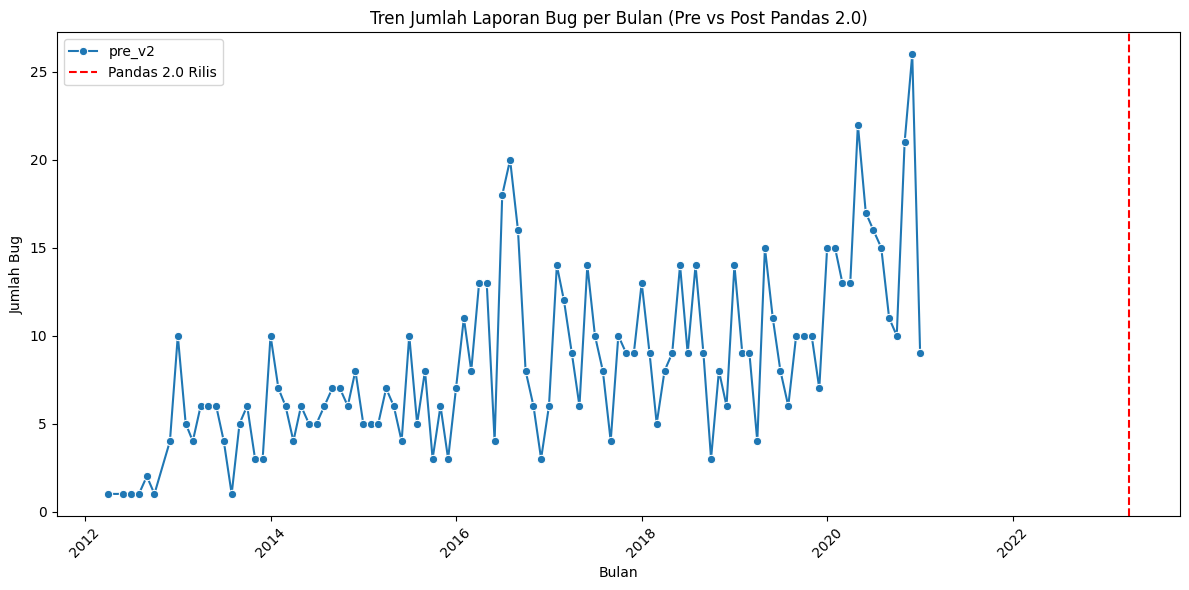

Preview rata-rata bug sebelum (λ̂1) = 8.41
Preview rata-rata bug sesudah (λ̂2) = nan


In [17]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# Plot RQ2
plt.figure(figsize=(12, 6))
# Convert period ke string agar mudah diplot dengan seaborn
monthly_bugs['timestamp'] = monthly_bugs['yearmonth'].dt.to_timestamp()
monthly_bugs = monthly_bugs.sort_values("timestamp")

sns.lineplot(data=monthly_bugs, x='timestamp', y='bug_count', hue='period', marker="o")
plt.axvline(x=PANDAS_V2_DATE, color="red", linestyle="--", label="Pandas 2.0 Rilis")

plt.xticks(rotation=45)
plt.title("Tren Jumlah Laporan Bug per Bulan (Pre vs Post Pandas 2.0)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Bug")
plt.legend()
plt.tight_layout()
plt.show()

# Preview rata-rata (Lambda Poisson)
pre_data = monthly_bugs[monthly_bugs['period'] == 'pre_v2']['bug_count']
post_data = monthly_bugs[monthly_bugs['period'] == 'post_v2']['bug_count']
lam_pre = monthly_bugs[monthly_bugs['period'] == 'pre_v2']['bug_count'].mean()
lam_post = monthly_bugs[monthly_bugs['period'] == 'post_v2']['bug_count'].mean()
print(f"Preview rata-rata bug sebelum (λ̂1) = {lam_pre:.2f}")
print(f"Preview rata-rata bug sesudah (λ̂2) = {lam_post:.2f}")

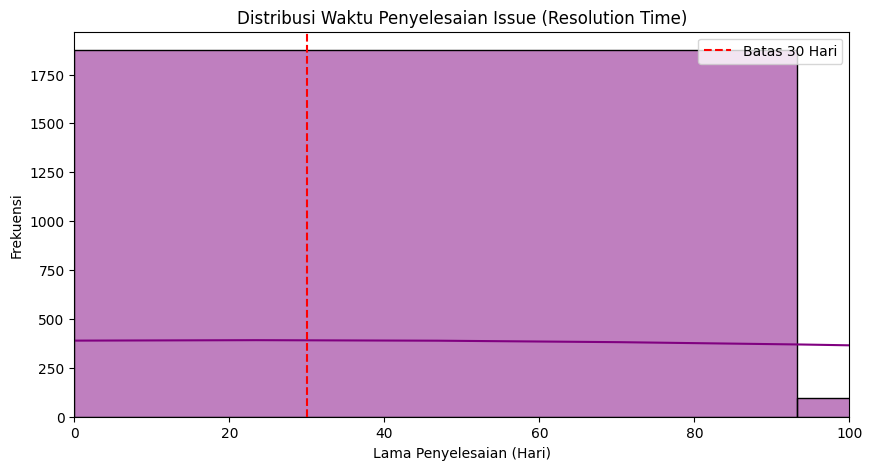

Probabilitas empiris issue > 30 hari: 0.6105


In [18]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# Plot RQ3
plt.figure(figsize=(10, 5))
sns.histplot(df_issues['resolution_days'], bins=50, kde=True, color="purple")
plt.axvline(30, color='red', linestyle='--', label='Batas 30 Hari')

plt.xlim(0, 100) # Potong visualisasi di 100 hari agar tidak melebar
plt.title("Distribusi Waktu Penyelesaian Issue (Resolution Time)")
plt.xlabel("Lama Penyelesaian (Hari)")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

# Hitung probabilitas empiris
lebih_dari_30 = (df_issues['resolution_days'] > 30).sum()
total_issue = len(df_issues)
print(f"Probabilitas empiris issue > 30 hari: {lebih_dari_30 / total_issue:.4f}")